In [16]:
import sys
!{sys.executable} -m pip install yfinance --upgrade --user

Looking in links: /usr/share/pip-wheels


In [17]:
import yfinance as yf

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from scipy.optimize import brentq
from scipy.optimize import minimize
from datetime import datetime

---
## RAW VISUALIZATION OF THE VOLATILITY SMILE
---

The Black–Scholes model assumes that volatility is constant for all options, regardless of their strike price, but in practice this assumption does not hold: when we plot implied volatility against the strike using real market data, we observe a pattern called the volatility smile, where implied volatility is lowest for at-the-money (ATM) options and increases for both deep in-the-money (ITM) and deep out-of-the-money (OTM) options, forming a U-shaped curve that reflects how markets assign different levels of risk (such as crash risk or extreme movements) depending on how far the strike is from the current price.

In [29]:
assets = ["SPY", "AAPL", "TSLA"]

I will work with the following assets :
- SPY : An Exchange-Traded Fund that tracks the S&P 500 index, often used as a proxy for the American market
- Apple Inc. : A stock of one of the largest tech companies in the world
- Tesla Inc. : A stock with higher risk and uncertainty

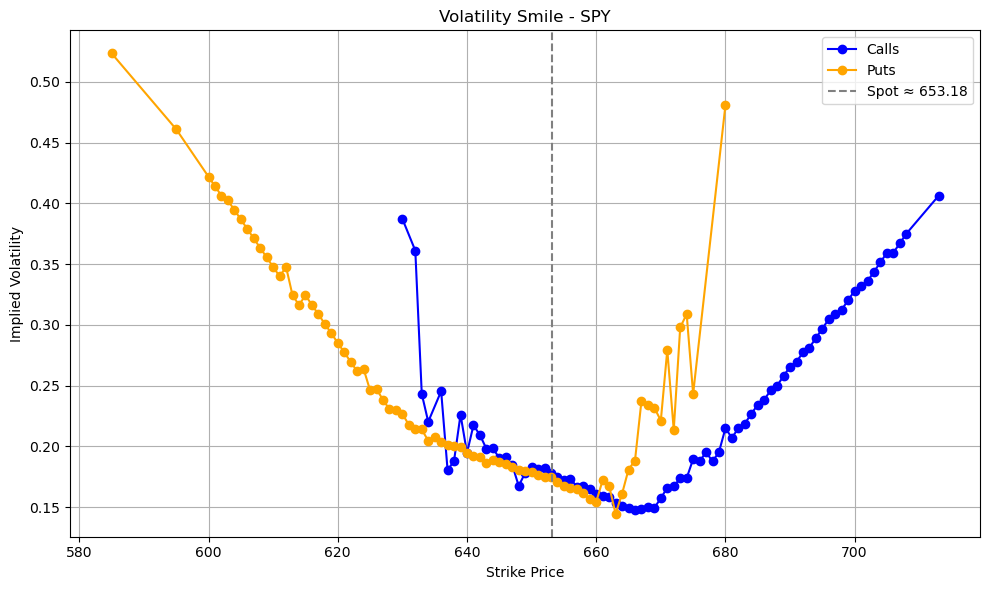

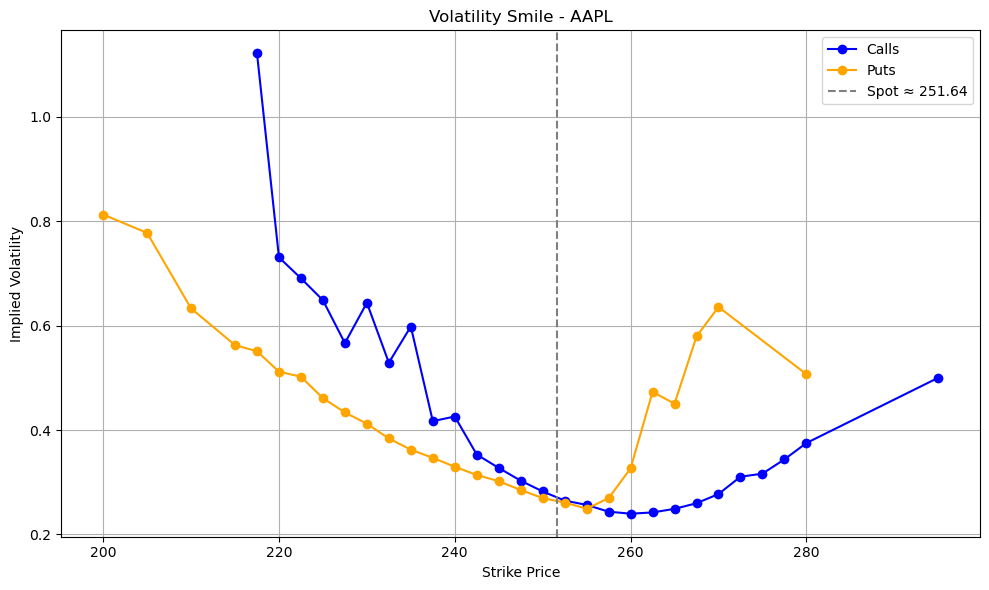

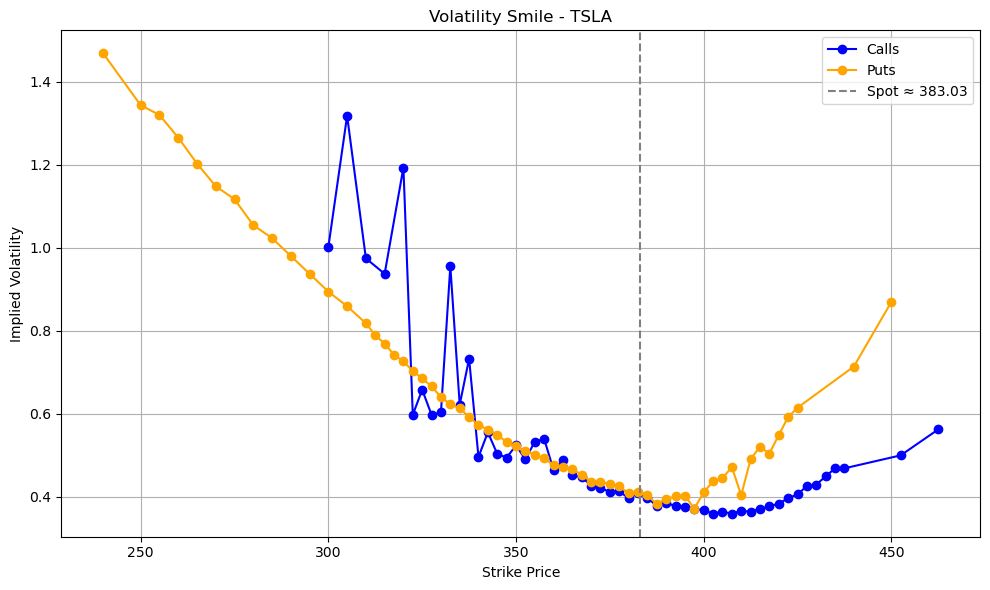

In [30]:
for ticker in assets:
    stock = yf.Ticker(ticker)

    # Step 1: choose expiration
    expiration = stock.options[1]
    option_chain = stock.option_chain(expiration)

    # Step 2: spot price
    spot = stock.history(period="1d")["Close"].iloc[-1]

    # Step 3: calls & puts
    calls = option_chain.calls
    puts = option_chain.puts

    # Step 4: filtering
    filtered_calls = calls[
        (calls['impliedVolatility'] > 0.01) &
        (calls['impliedVolatility'] < 1.5) &
        (calls['volume'] > 0) &
        (puts['bid'] > 0) &
        (puts['ask'] > 0) &
        (puts['openInterest'] > 10)
    ].copy()

    filtered_puts = puts[
        (puts['impliedVolatility'] > 0.01) &
        (puts['impliedVolatility'] < 1.5) &
        (puts['volume'] > 0) &
        (puts['bid'] > 0) &
        (puts['ask'] > 0) &
        (puts['openInterest'] > 10)
    ].copy()

    # Step 5: sort
    filtered_calls = filtered_calls.sort_values(by='strike')
    filtered_puts = filtered_puts.sort_values(by='strike')

    # Step 6: plot (one figure per asset)
    plt.figure(figsize=(10, 6))

    plt.plot(
        filtered_calls['strike'],
        filtered_calls['impliedVolatility'],
        '-o',
        label="Calls",
        color='blue'
    )

    plt.plot(
        filtered_puts['strike'],
        filtered_puts['impliedVolatility'],
        '-o',
        label="Puts",
        color='orange'
    )

    plt.axvline(
        spot,
        color='gray',
        linestyle='--',
        label=f"Spot ≈ {spot:.2f}"
    )

    # Step 7: plot settings
    plt.title(f"Volatility Smile - {ticker}")
    plt.xlabel("Strike Price")
    plt.ylabel("Implied Volatility")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.show()

---
## CLEANED VISUALIZATION OF THE VOLATILITY SMILE
---

To plot a clean volatility smile, filters on IV, volumes and prices are not enough. 
It is important to keep only meaningful options. 
We only keep OTM options to avoid duplicating the same information, they already contain all the useful market information.
A call and a put with the same strike are linked by the put-call parity. 
Thus, an ITM calls and OTM put hold the same information, and so does an ITM out and an OTM call.

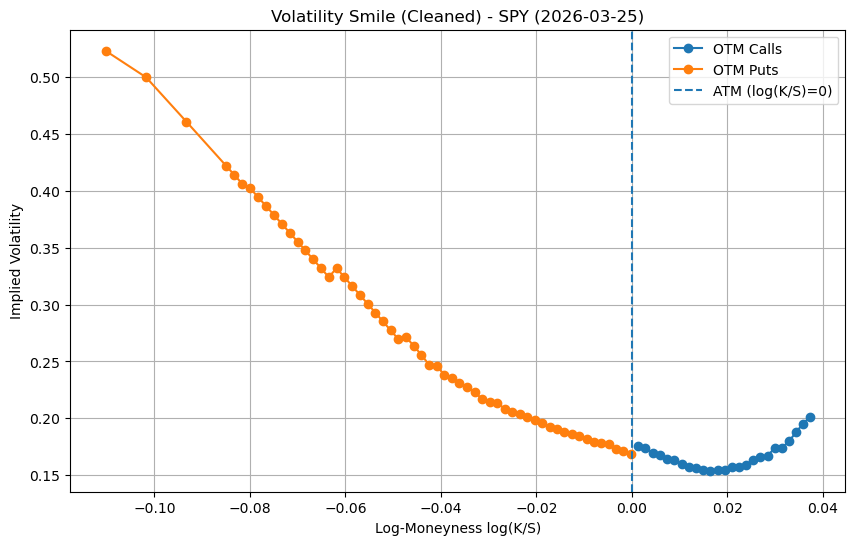

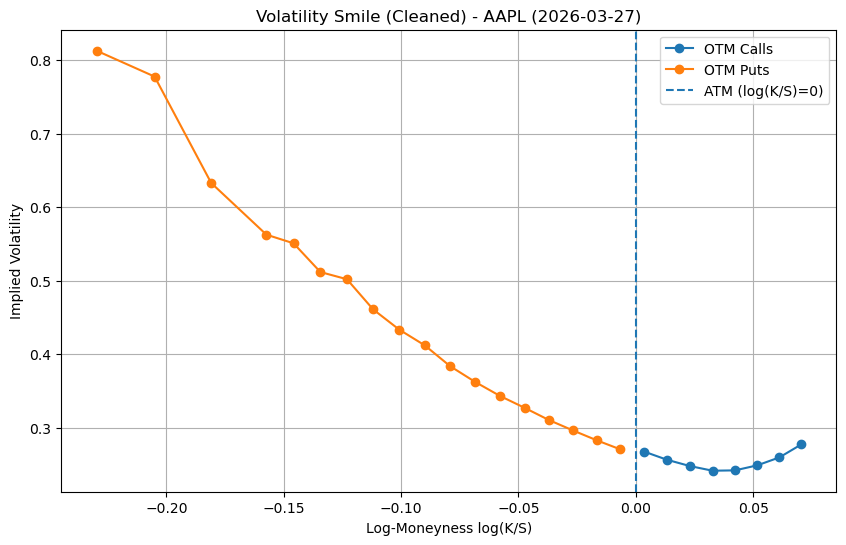

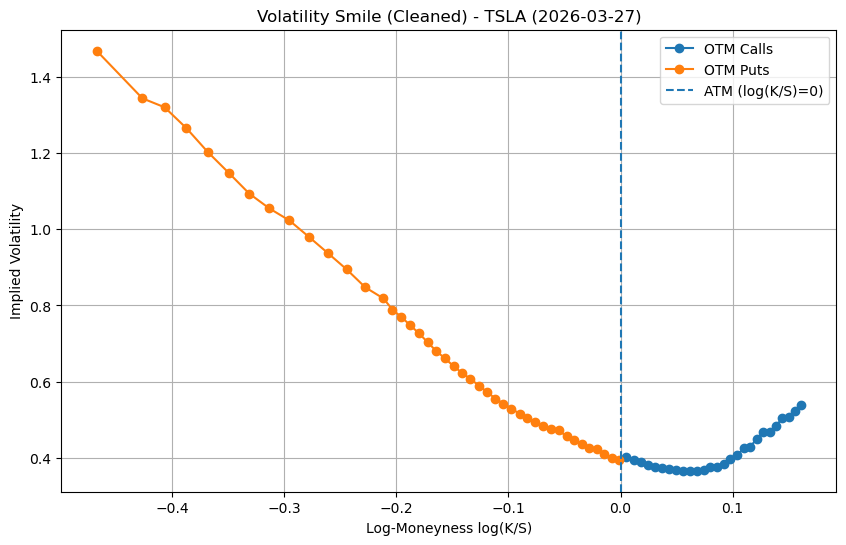

In [31]:
for ticker in assets:
    stock = yf.Ticker(ticker)

    expiration = stock.options[1]
    option_chain = stock.option_chain(expiration)

    spot = stock.history(period="1d")["Close"].iloc[-1]

    calls = option_chain.calls.copy()
    puts = option_chain.puts.copy()

    def clean_options(df):
        df = df[
            (df['impliedVolatility'] > 0.01) &
            (df['impliedVolatility'] < 1.5) &
            (df['bid'] > 0) &
            (df['ask'] > 0) &
            (df['openInterest'] > 10)
        ].copy()
        return df

    calls = clean_options(calls)
    puts = clean_options(puts)

    # Computation of log moneyness log(K/S)
    calls['log_moneyness'] = np.log(calls['strike'] / spot)
    puts['log_moneyness'] = np.log(puts['strike'] / spot)

    calls_otm = calls[calls['strike'] >= spot]   # OTM calls
    puts_otm = puts[puts['strike'] <= spot]      # OTM puts

    calls_otm = calls_otm.sort_values(by='log_moneyness')
    puts_otm = puts_otm.sort_values(by='log_moneyness')

    plt.figure(figsize=(10, 6))

    plt.plot(
        calls_otm['log_moneyness'],
        calls_otm['impliedVolatility'],
        'o-',
        label='OTM Calls'
    )

    plt.plot(
        puts_otm['log_moneyness'],
        puts_otm['impliedVolatility'],
        'o-',
        label='OTM Puts'
    )

    plt.axvline(0, linestyle='--', label='ATM (log(K/S)=0)')

    plt.title(f"Volatility Smile (Cleaned) - {ticker} ({expiration})")
    plt.xlabel("Log-Moneyness log(K/S)")
    plt.ylabel("Implied Volatility")
    plt.legend()
    plt.grid(True)

    plt.show()

---
## FROM OBSERVATIONS TO MODELS
---

The SABR Model was designed to explain and reproduce the volatility smile observed in the market.

SABR assumes that not only asset prices but also volatility move randomly, though both are linked.
- dF=σ(F**β)dW
- dσ=νσdZ
- dW and dZ are correlated

SABR has 4 parameters being :
- α : controls the level of the volatility
- β : controls the shape of the smile
- correlation ρ : controls the assymetry of the smile
- volatility of volatility ν : controls how much the volatility moves

With the appropriate parameters, the iv predicted by SABR matches the observed iv.

Let's :
1. Define a SABR function (using the Hagan  approximation formula) to compute the theoretical iv using the 4 parameters.
2. Find the parameters such that the SABR predictions fit the market data best.
3. Compute theoretical iv using theses parameters and plot the curve on the market data.

In [34]:
# This function computes the implied volatility predicted by SABR
def sabr_implied_vol(F, K, T, alpha, beta, rho, nu):
    
    # An option ATM is handled separately
    if F == K:
        term1 = alpha / (F**(1 - beta)) # Base level
        term2 = (
            ((1 - beta)**2 / 24) * (alpha**2 / (F**(2 - 2*beta))) +
            (rho * beta * nu * alpha) / (4 * (F**(1 - beta))) +
            (nu**2 * (2 - 3*rho**2) / 24)
        ) * T # Correction term depending on time and parameters
        return term1 * (1 + term2)

    # General case for F ≠ K
    logFK = np.log(F / K) # Log-moneyness
    FK_beta = (F * K)**((1 - beta) / 2)
    z = (nu / alpha) * FK_beta * logFK
    x_z = np.log((np.sqrt(1 - 2*rho*z + z**2) + z - rho) / (1 - rho))
    
    term1 = alpha / (FK_beta * (1 + ((1 - beta)**2 / 24) * logFK**2)) # Base level
    term2 = z / x_z # Skew component
    term3 = 1 + (
        ((1 - beta)**2 / 24) * (alpha**2 / (FK_beta**2)) +
        (rho * beta * nu * alpha) / (4 * FK_beta) +
        (nu**2 * (2 - 3*rho**2) / 24)
    ) * T # Correction term depending on time and parameters
    return term1 * term2 * term3


# This function measures how well SABR fits the market
def sabr_loss(params, F, K, T, market_iv, beta):
    alpha, rho, nu = params

    if alpha <= 0 or nu <= 0 or abs(rho) >= 1: # Ensures parameters are valid
        return 1e10

    model_iv = np.array([
        sabr_implied_vol(F, k, T, alpha, beta, rho, nu)
        for k in K
    ]) # SABR volatility computed for each strike

    return np.mean((model_iv - market_iv)**2) # Mean squared error

SABR parameters: alpha=4.3523, rho=-0.3820, nu=10.2032


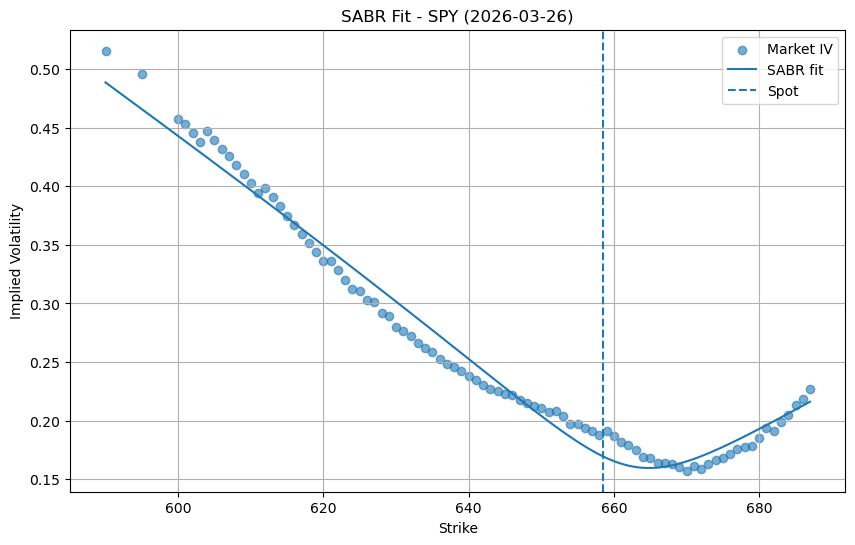

SABR parameters: alpha=3.3601, rho=-0.3499, nu=9.6316


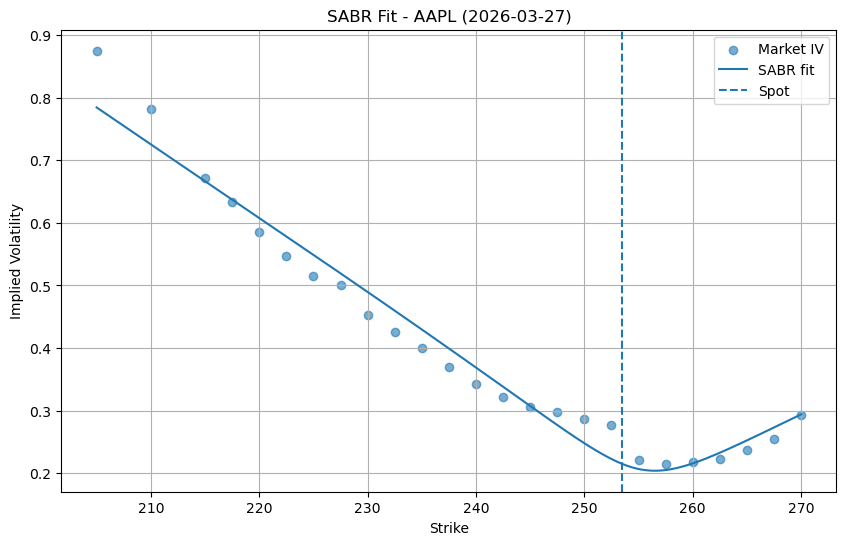

SABR parameters: alpha=6.2199, rho=-0.2414, nu=9.5390


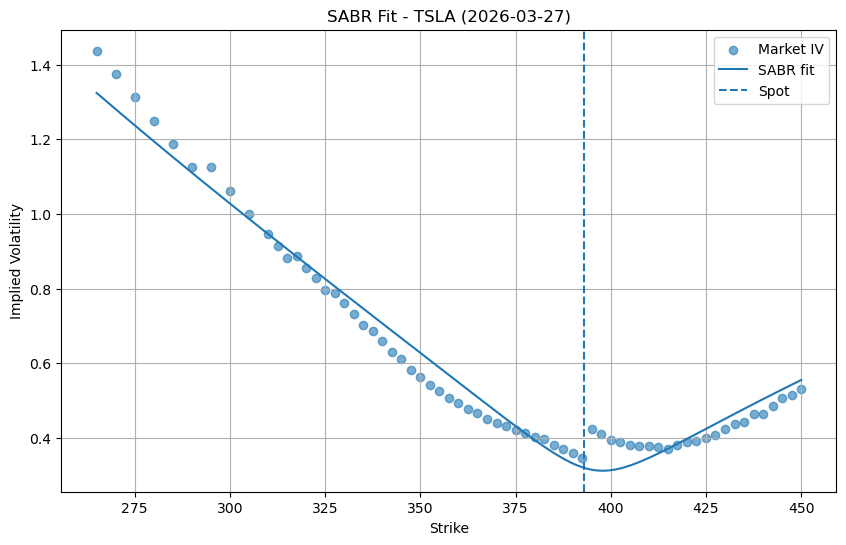

In [35]:
for ticker in assets:

    # Data is prepared as in the previous section
    stock = yf.Ticker(ticker)

    expiration = stock.options[1]
    option_chain = stock.option_chain(expiration)

    spot = stock.history(period="1d")["Close"].iloc[-1]

    today = datetime.today()
    T = (datetime.strptime(expiration, "%Y-%m-%d") - today).days / 365

    calls = option_chain.calls.copy()
    puts = option_chain.puts.copy()

    def clean(df):
        df = df[
            (df['impliedVolatility'] > 0.01) &
            (df['impliedVolatility'] < 1.5) &
            (df['bid'] > 0) &
            (df['ask'] > 0) &
            (df['openInterest'] > 10)
        ].copy()

        df['mid'] = (df['bid'] + df['ask']) / 2
        df = df[df['mid'] > 0]

        return df

    calls = clean(calls)
    puts = clean(puts)

    calls['log_moneyness'] = np.log(calls['strike'] / spot)
    puts['log_moneyness'] = np.log(puts['strike'] / spot)

    calls_otm = calls[calls['strike'] >= spot]
    puts_otm = puts[puts['strike'] <= spot]

    K = np.concatenate([puts_otm['strike'], calls_otm['strike']])
    iv = np.concatenate([puts_otm['impliedVolatility'], calls_otm['impliedVolatility']])

    idx = np.argsort(K)
    K = K[idx]
    iv = iv[idx]

    # The goal is then to find the best calibration parameters for the SABR model to match real data
    F = spot
    beta = 0.5
    initial_guess = [0.2, -0.3, 0.5] # Starting points
    result = minimize( # Find parameters that minimize the loss function
        sabr_loss,
        initial_guess,
        args=(F, K, T, iv, beta), # Fixed inputs
        method='Nelder-Mead' # Trial-and-error search algorithm
    )

    alpha, rho, nu = result.x

    print(f"SABR parameters: alpha={alpha:.4f}, rho={rho:.4f}, nu={nu:.4f}")

    # Compute the SABR model using these parameters
    K_grid = np.linspace(min(K), max(K), 200)

    sabr_iv = [
        sabr_implied_vol(F, k, T, alpha, beta, rho, nu)
        for k in K_grid
    ]

    # Plot
    plt.figure(figsize=(10, 6))

    plt.scatter(K, iv, label="Market IV", alpha=0.6)
    plt.plot(K_grid, sabr_iv, label="SABR fit")

    plt.axvline(spot, linestyle='--', label="Spot")

    plt.title(f"SABR Fit - {ticker} ({expiration})")
    plt.xlabel("Strike")
    plt.ylabel("Implied Volatility")
    plt.legend()
    plt.grid(True)

    plt.show()

---
## THE SKEW
---

The 3 plots above suggest that the volatility smile is not symmetric. This is the skew. They also suggest that deep OTM puts have much higher iv than OTM calls. In SABR, the skew is controlled by ρ, and thus negative in our case.